# Predicting IMDb Movie Ratings Using Machine Learning

# 1. Introduction

The film industry generates large amounts of data related to audience tastes, critic reviews, box office performance, and movie characteristics. Analyzing this data can provide insights into the factors associated with highly rated and commercially successful films.

This project explores the IMDb Top 1000 Movies dataset obtained from Kaggle. The objective of the analysis is to identify patterns and relationships between movie features such as genre, runtime, critic scores, audience engagement, and revenue, and their influence on IMDb ratings.

The project follows a complete data science workflow including data cleaning, exploratory data analysis (EDA), feature engineering, machine learning modeling, and model evaluation. Visualizations were used to examine trends in movie ratings, genre distributions, and correlations between variables. Additional features such as Movie Age and Revenue per Vote were engineered to enhance predictive analysis.

A linear regression model was developed to predict IMDb ratings using movie metadata and audience engagement metrics. Model performance was evaluated using R² score and Root Mean Squared Error (RMSE).

The analysis was conducted using Python libraries including pandas, numpy, matplotlib, seaborn, and scikit-learn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../imdb analysis project/imdb_top_1000.csv")

# 2. Data Cleaning

The dataset structure, data types, and summary statistics must be examined to understand the available variables and identify potential issues.

In [3]:
df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [5]:
df.describe()

,IMDB_Rating,Meta_score,No_of_Votes
count,1000.000000,843.000000,1.000000e+03
mean,7.949300,77.971530,2.736929e+05
std,0.275491,12.376099,3.273727e+05
min,7.600000,28.000000,2.508800e+04
25%,7.700000,70.000000,5.552625e+04
50%,7.900000,79.000000,1.385485e+05
75%,8.100000,87.000000,3.741612e+05
max,9.300000,100.000000,2.343110e+06


Clean the data: Handle missing values, correct formatting issues, and convert columns such as runtime and gross revenue into usable numerical formats.

In [6]:
df.isnull().sum()

Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

In [7]:
df = df.dropna()

Missing values were identified in the Certificate, Meta_score, and Gross columns. Rows containing null values were removed to ensure consistency and improve the reliability of the analysis and predictive modeling.

In [8]:
df['Gross'] = df['Gross'].str.replace(',', '')
df['Gross'] = pd.to_numeric(df['Gross'])

In [9]:
df['Runtime'] = df['Runtime'].str.replace(' min', '')
df['Runtime'] = pd.to_numeric(df['Runtime'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 997
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    714 non-null    object 
 1   Series_Title   714 non-null    object 
 2   Released_Year  714 non-null    object 
 3   Certificate    714 non-null    object 
 4   Runtime        714 non-null    int64  
 5   Genre          714 non-null    object 
 6   IMDB_Rating    714 non-null    float64
 7   Overview       714 non-null    object 
 8   Meta_score     714 non-null    float64
 9   Director       714 non-null    object 
 10  Star1          714 non-null    object 
 11  Star2          714 non-null    object 
 12  Star3          714 non-null    object 
 13  Star4          714 non-null    object 
 14  No_of_Votes    714 non-null    int64  
 15  Gross          714 non-null    int64  
dtypes: float64(2), int64(3), object(11)
memory usage: 94.8+ KB


In [11]:
df.isnull().sum()

Poster_Link      0
Series_Title     0
Released_Year    0
Certificate      0
Runtime          0
Genre            0
IMDB_Rating      0
Overview         0
Meta_score       0
Director         0
Star1            0
Star2            0
Star3            0
Star4            0
No_of_Votes      0
Gross            0
dtype: int64

# 3. Exploratory Data Analysis

Trends and relationships between variables are analyzed using statistical summaries and visualizations.

First, the movies were analyzed by genre to see which genres consistently get higher ratings.

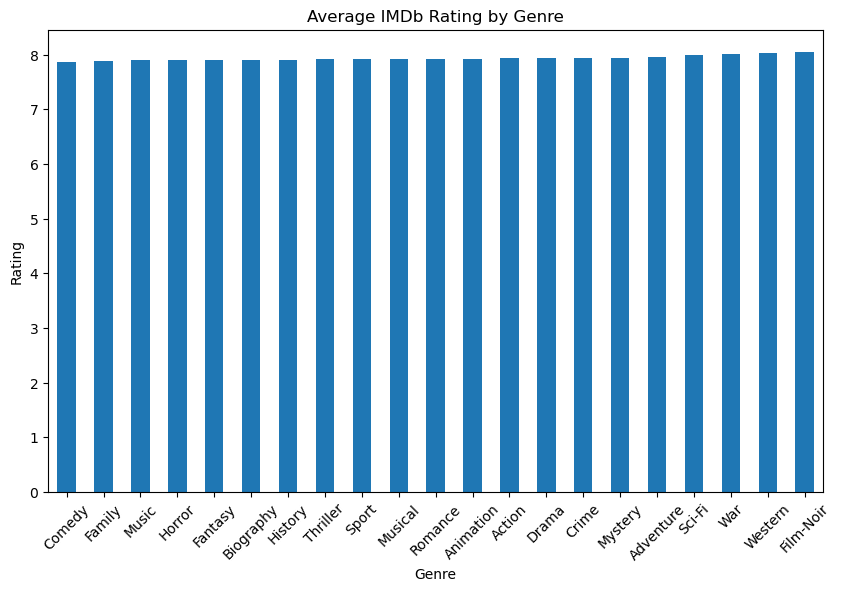

In [12]:
df['Genre'] = df['Genre'].str.split(', ')
df = df.explode('Genre')

genre_ratings = df.groupby('Genre')['IMDB_Rating'].mean().sort_values()
plt.figure(figsize=(10,6))
genre_ratings.plot(kind='bar')
plt.title("Average IMDb Rating by Genre")
plt.ylabel("Rating")
plt.xticks(rotation=45)
plt.savefig('images/genre_chart.png', bbox_inches='tight')
plt.show()

Average IMDb ratings were relatively consistent across genres within the Top 1000 dataset, although Film-Noir, Western, and War films showed slightly higher average ratings. 

It is possible that some genres like Western and Film-Noir have fewer movies in the dataset, so the number of movies in each genre was investigated to see if it has an effect on the average IMDb ratings.

           Average_Rating  Movie_Count
Genre                                 
Film-Noir            8.05            6
Western              8.04           16
War                  8.01           29
Sci-Fi               7.99           56
Adventure            7.96          163
Mystery              7.95           70
Crime                7.94          142
Drama                7.94          500
Action               7.94          140
Animation            7.93           63
Romance              7.92           88
Musical              7.92           11
Sport                7.92           17
Thriller             7.92           99
History              7.91           38
Biography            7.91           88
Fantasy              7.90           55
Horror               7.90           18
Music                7.90           27
Family               7.88           43
Comedy               7.87          161


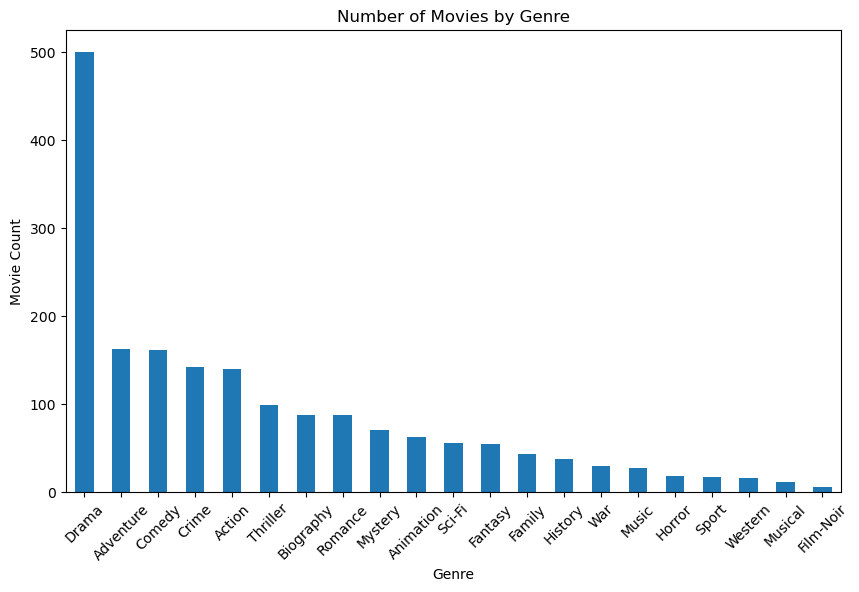

In [13]:
genre_summary = df.groupby('Genre').agg({
    'IMDB_Rating': 'mean',
    'Series_Title': 'count'
})

genre_summary.columns = ['Average_Rating', 'Movie_Count']

genre_summary = genre_summary.sort_values(
    by='Average_Rating',
    ascending=False
)

print(genre_summary.round(2))

genre_counts = df['Genre'].value_counts()
plt.figure(figsize=(10,6))
genre_counts.plot(kind='bar')

plt.title("Number of Movies by Genre")
plt.xlabel("Genre")
plt.ylabel("Movie Count")
plt.xticks(rotation=45)

plt.show()

Although Film-Noir and Western genres showed the highest average IMDb ratings, these categories contained relatively few movies, making their averages less representative of audience preferences than larger genres such as Drama and Comedy.

What movie features are strongly related to IMDb ratings?

A correlation heatmap was created to see how the numerical values relate to each other.

               IMDB_Rating  Meta_score   Runtime     Gross  No_of_Votes  \
IMDB_Rating       1.000000    0.291970  0.253680  0.142947     0.609705   
Meta_score        0.291970    1.000000 -0.006513  0.001933     0.043940   
Runtime           0.253680   -0.006513  1.000000  0.167014     0.211539   
Gross             0.142947    0.001933  0.167014  1.000000     0.564511   
No_of_Votes       0.609705    0.043940  0.211539  0.564511     1.000000   
Released_Year    -0.164007   -0.274620 -0.022361  0.253102     0.219122   

               Released_Year  
IMDB_Rating        -0.164007  
Meta_score         -0.274620  
Runtime            -0.022361  
Gross               0.253102  
No_of_Votes         0.219122  
Released_Year       1.000000  


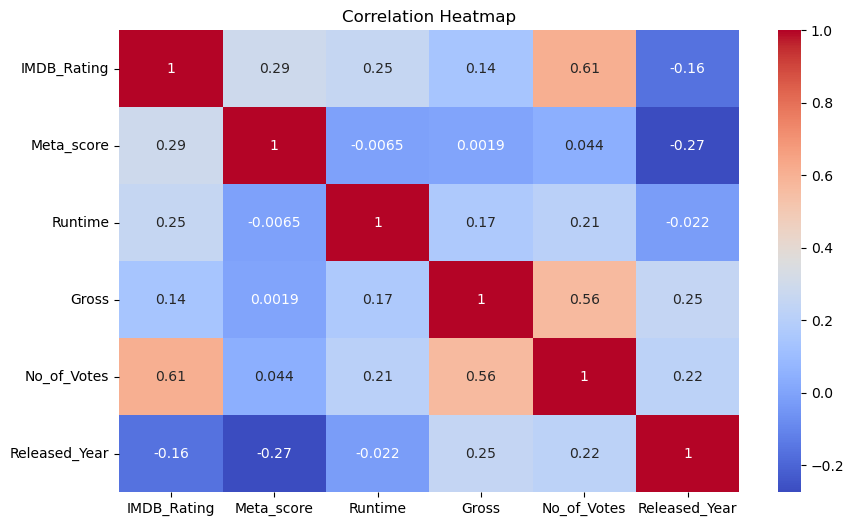

In [14]:
df['Released_Year'] = pd.to_numeric(
    df['Released_Year'],
    errors='coerce'
)
df = df.dropna()
numeric_cols = ['IMDB_Rating','Meta_score','Runtime','Gross','No_of_Votes','Released_Year']
corr = df[numeric_cols].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
print(corr)
plt.title("Correlation Heatmap")
plt.savefig('images/heatmap.png', bbox_inches='tight')
plt.show()

The correlation analysis revealed that the number of audience votes had the strongest relationship with IMDb ratings, having a correlation coefficient of 0.61, suggesting that highly engaged movies tend to receive stronger audience evaluations. Gross revenue was also positively associated with vote count (0.56), indicating a connection between popularity and commercial success. Release year showed a slight negative correlation with IMDb ratings (-0.16), suggesting that older classic films in the dataset tend to maintain strong audience reception.

Next, an analysis was done to determine how IMDb ratings are spread out across the dataset to determine how similarly the movies are rated.

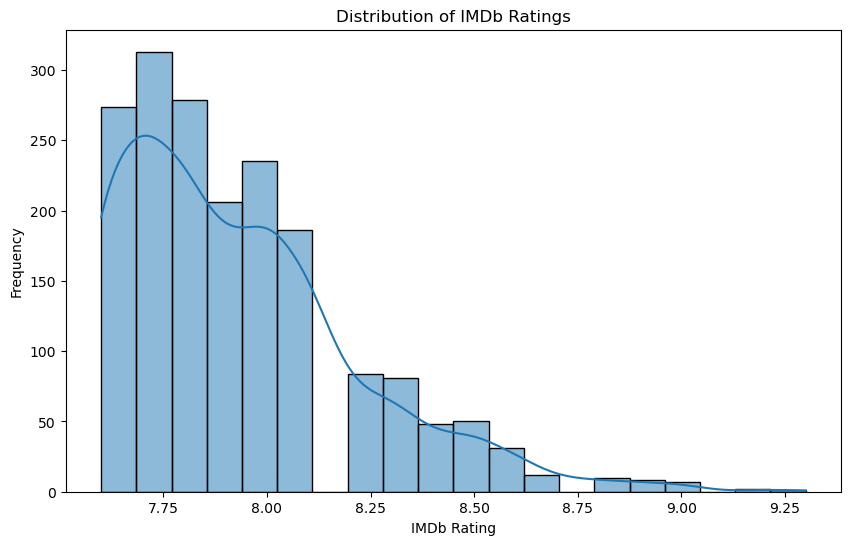

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(df['IMDB_Rating'], bins=20, kde=True)

plt.title("Distribution of IMDb Ratings")
plt.xlabel("IMDb Rating")
plt.ylabel("Frequency")
plt.savefig('images/histogram.png', bbox_inches='tight')
plt.show()

The distribution of IMDb ratings showed that most films were concentrated between ratings of 7.5 and 8.0, reflecting the dataset’s focus on highly rated movies. Extremely high ratings were relatively rare, with very few movies above 8.8 rating, indicating that even among top-ranked films, exceptional audience rating is uncommon. This dataset is biased towards highly rated movies and not representative of the broader movie population.

How has movie representation in the dataset changed over the years?

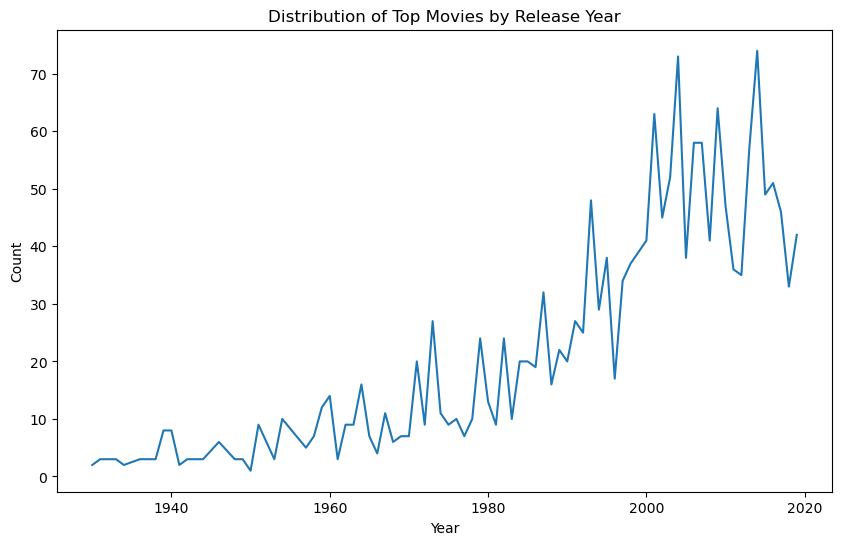

In [16]:
movies_per_year = df['Released_Year'].value_counts().sort_index()
plt.figure(figsize=(10,6))
movies_per_year.plot()
plt.title("Distribution of Top Movies by Release Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.savefig('images/release_year_distribution.png',
            bbox_inches='tight')
plt.show()

From the graph, the number of movies produced generally increases over time. However, there were generally fewer movies produced from around 1930 to 1960 in this dataset. This could be due to lower movie production in the past, fewer classics being highly ranked, or simply better access to newer movies. There was significant increase after the 1980s with major peaks in the 2000s and 2010s. This trend may reflect growth in global film production, increased audience participation on IMDb, and greater visibility of modern films. This graph shows representation of movies within this dataset, it does not mean that movies got better over time.

# 4. Feature Engineering

To improve predictive analysis, additional features were engineered from the existing dataset. These new variables were designed to capture relationships between audience engagement, financial performance, and movie longevity that may not be fully represented by the original columns.

Revenue per Vote was created to measure how much revenue a movie generated relative to audience engagement. This feature combines financial performance and popularity into a single metric.

In [17]:
df['Revenue_per_Vote'] = df['Gross'] / df['No_of_Votes']
df['Movie_Age'] = 2026 - df['Released_Year']
df[['Series_Title',
    'Revenue_per_Vote',
    'Movie_Age']].head()

,Series_Title,Revenue_per_Vote,Movie_Age
0,The Shawshank Redemption,12.095663,32.0
1,The Godfather,83.293730,54.0
1,The Godfather,83.293730,54.0
2,The Dark Knight,232.220829,18.0
2,The Dark Knight,232.220829,18.0


In [18]:
df_ml = df.drop_duplicates(subset='Series_Title')

Given that movie age and released year contain nearly the same information, only movie age will be included in the machine learning model. The engineered features were incorporated into the machine learning model to evaluate whether they improved the prediction of IMDb ratings.

# 5. Machine Learning Model

After completing data cleaning, exploratory data analysis, and feature engineering, a machine learning model was developed to predict IMDb ratings based on movie characteristics and audience engagement metrics.

The objective of this section is to evaluate whether variables such as runtime, metascore, vote count, revenue, and engineered features can effectively predict IMDb ratings.

A linear regression model was selected because it provides an interpretable baseline for understanding relationships between numerical features and movie ratings. The dataset was divided into training and testing subsets to evaluate model performance on unseen data.

The following features were used in the model:

- Runtime
- Meta Score
- Number of Votes
- Gross Revenue
- Revenue per Vote
- Movie Age

The target variable for prediction was:

- IMDb Rating

In [19]:
X = df_ml[['Runtime',
           'Meta_score',
           'No_of_Votes',
           'Gross',
           'Revenue_per_Vote',
           'Movie_Age']]

y = df_ml['IMDB_Rating']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

The dataset was split into a training set and a testing set.

In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [22]:
predictions = model.predict(X_test)

In [23]:
from sklearn.metrics import mean_squared_error, r2_score

print("R² Score:", r2_score(y_test, predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, predictions)))

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)

R² Score: 0.5203043015853581
RMSE: 0.2011074227695637
            Feature   Coefficient
0           Runtime  1.515727e-03
1        Meta_score  4.691765e-03
2       No_of_Votes  6.202452e-07
3             Gross -5.041239e-10
4  Revenue_per_Vote -8.644128e-05
5         Movie_Age  3.581804e-03


# 6. Model Results and Interpretation

The linear regression model achieved an R² score of approximately 0.52, indicating that the selected features explained around 52% of the variation in IMDb ratings. The model also achieved a relatively low RMSE of 0.20, suggesting that predictions were generally close to actual movie ratings.

Among the predictors, Meta Score and Number of Votes showed positive relationships with IMDb ratings, indicating that critic reception and audience engagement contribute to higher audience evaluations. Movie Age also demonstrated a slight positive effect, suggesting that older classic films in the dataset tend to maintain strong ratings over time.

In contrast, Gross Revenue and Revenue per Vote had minimal influence on predicted ratings, implying that commercial success alone does not strongly determine audience perception of film quality.

# 7. Key Findings

- Audience engagement (number of votes) showed the strongest relationship with IMDb ratings.
- Most movies in the dataset were concentrated between ratings of 7.5 and 8.0.
- Older classic films tended to maintain slightly higher ratings.
- Revenue alone was not a strong predictor of IMDb ratings.
- The regression model explained approximately 52% of the variation in movie ratings.

# 8. Conclusion

This project analyzed the IMDb Top 1000 Movies dataset to identify factors associated with higher IMDb ratings and audience engagement.

The data preparation process involved cleaning missing values, converting variables into numerical formats, and engineering additional features such as Revenue per Vote and Movie Age. Exploratory data analysis revealed that ratings were relatively consistent across genres within the dataset, although certain genres such as Film-Noir and Western showed slightly higher average ratings. Correlation analysis demonstrated that audience engagement, measured by number of votes, had one of the strongest relationships with IMDb ratings and gross revenue.

The distribution analysis showed that most films were concentrated between IMDb ratings of 7.5 and 8.0, reflecting the dataset’s focus on highly rated movies. Additionally, movies released after the 1980s were more heavily represented in the dataset compared to earlier decades.

A linear regression model was developed to predict IMDb ratings using movie metadata and engineered features. The model achieved an R² score of approximately 0.52 and an RMSE of 0.20, indicating moderate predictive performance. Meta Score, Number of Votes, and Movie Age showed positive relationships with IMDb ratings, while Gross Revenue demonstrated minimal predictive influence.

Overall, the project demonstrated an end-to-end data science workflow involving data cleaning, exploratory analysis, feature engineering, machine learning, and model evaluation using Python libraries including pandas, seaborn, matplotlib, and scikit-learn.

# 9. Potential Improvements

Potential future improvements for this project include:

- testing additional machine learning models such as Random Forest Regression to capture more complex patterns
- incorporating natural language processing on movie overviews
- adding genre encoding techniques for predictive modeling to learn about interactions between genres and audience reception
- developing an interactive dashboard using Tableau or Power BI to improve communication of insights
- performing feature scaling and hyperparameter optimizationto improve model stability and algorithm performance